In [1]:
import sys
import os

# Adds the project root (one folder up from 'notebooks') to the path
sys.path.append(os.path.abspath(os.path.join('..')))

# Now the imports will work
from pricing.black_scholes import black_scholes_price
from pricing.greeks import GreeksCalculator


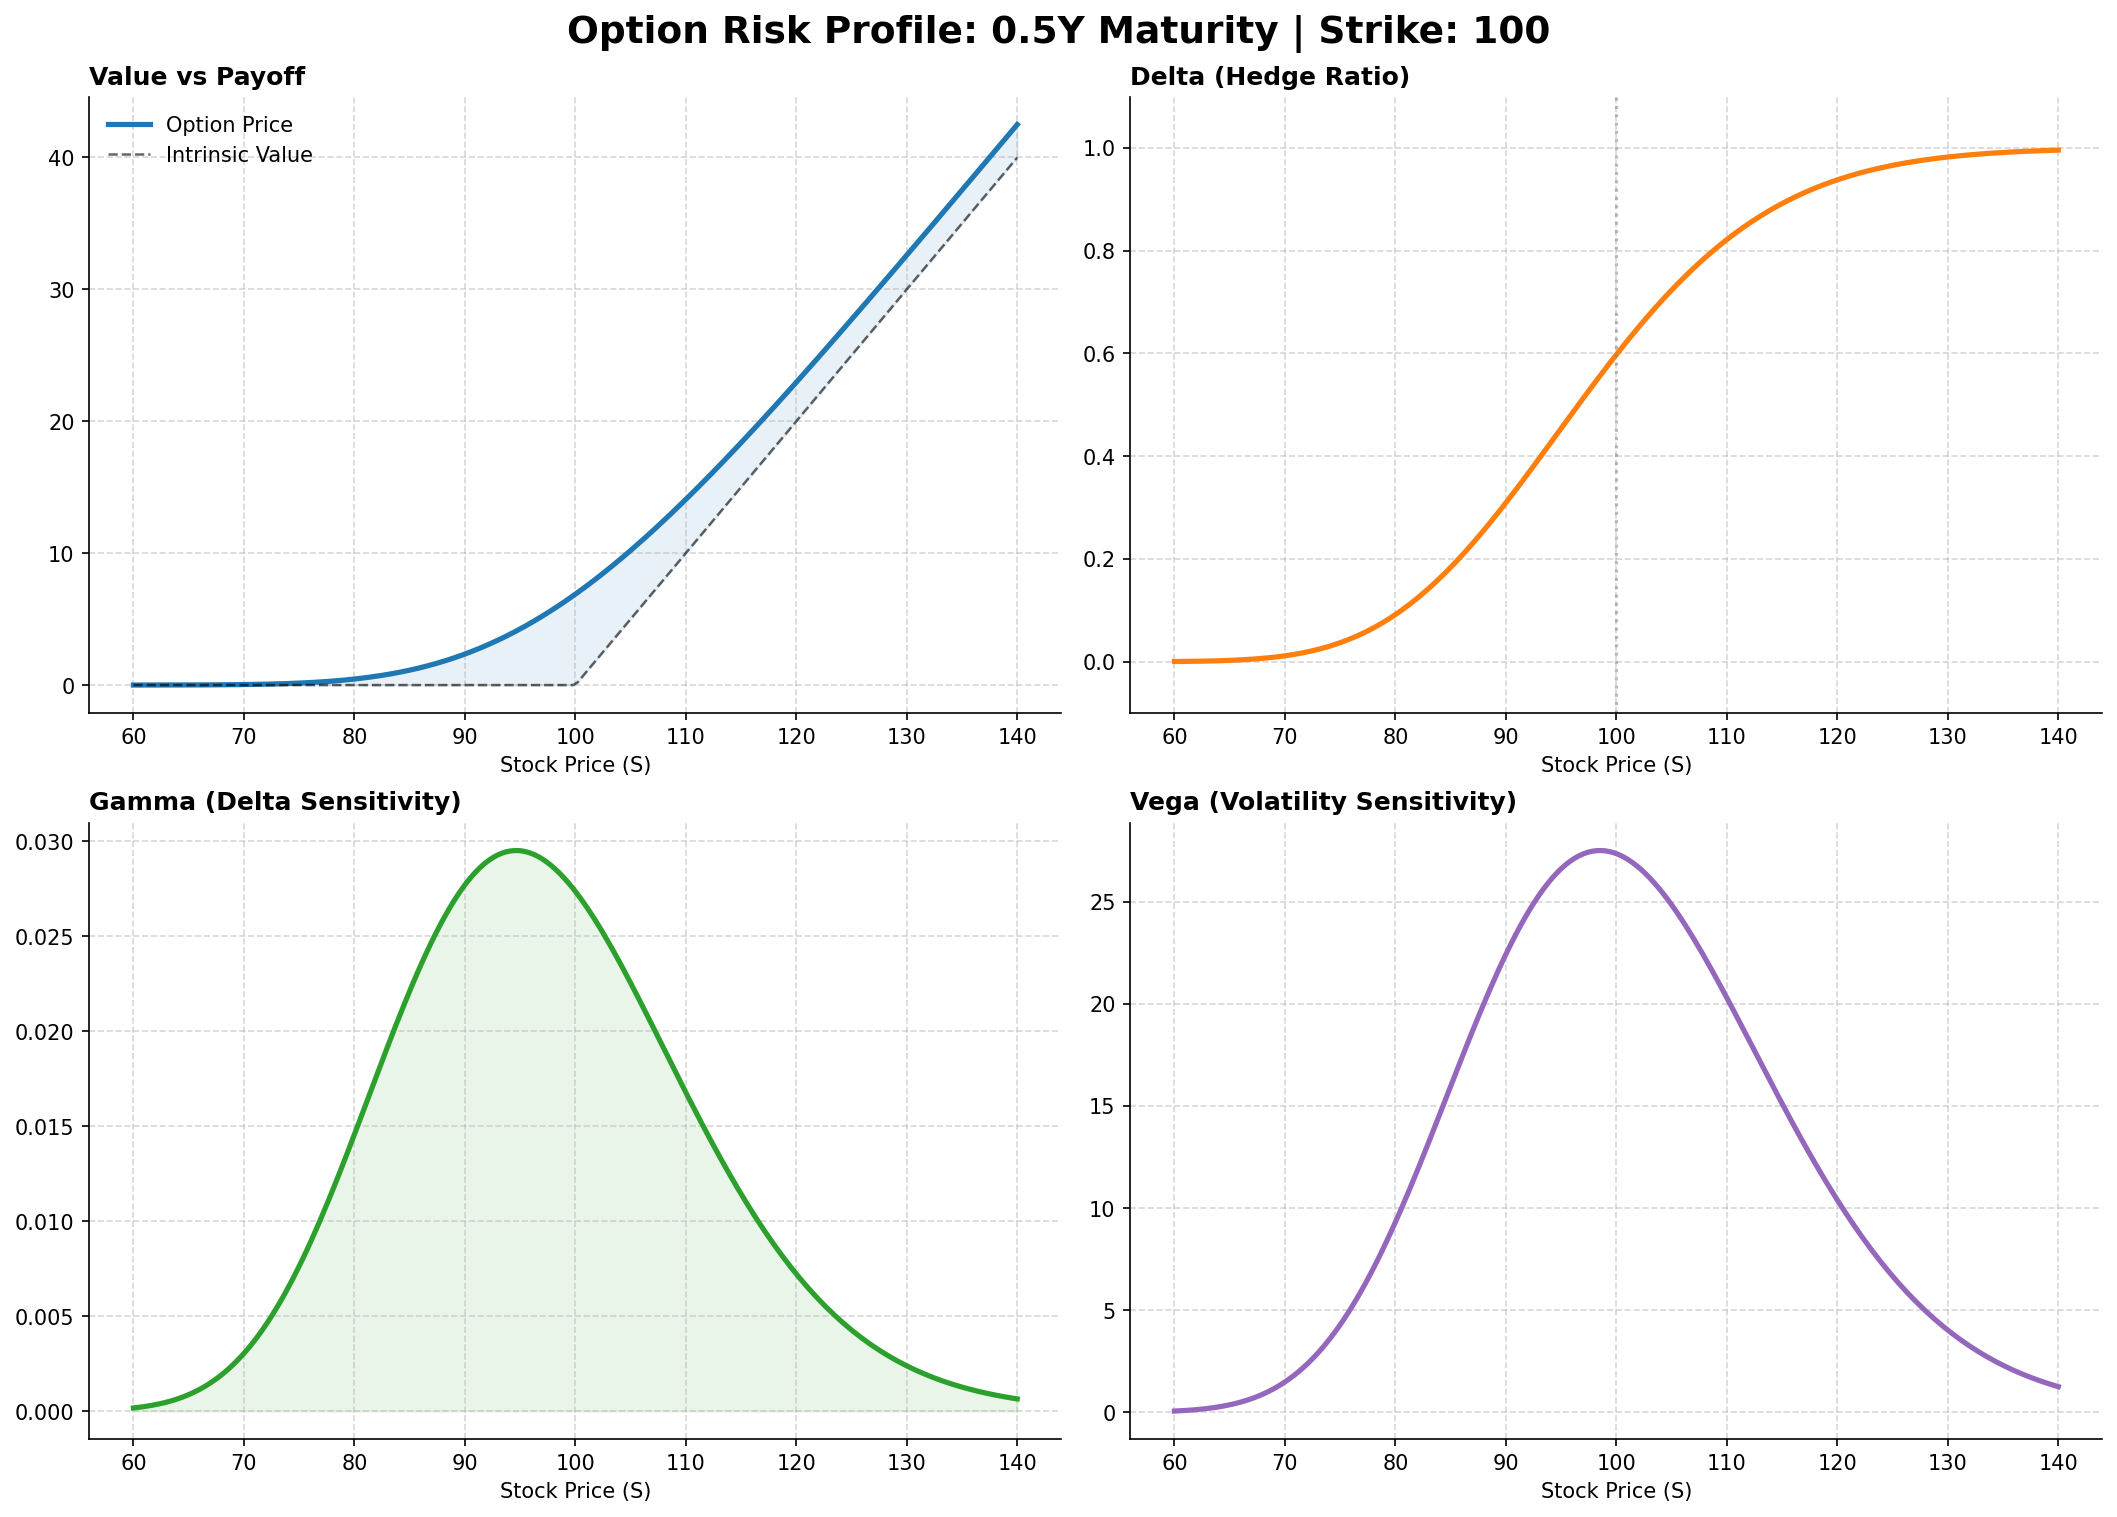

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Optional: just for better color palettes

# 1. Configuration for high-resolution & aesthetics
plt.style.use('seaborn-v0_8-muted') # Clean, modern look
plt.rcParams['figure.dpi'] = 150      # Sharper images
plt.rcParams['font.family'] = 'sans-serif'

# 2. Setup Data
S_range = np.linspace(60, 140, 200)
K, r, sigma, T = 100, 0.05, 0.2, 0.5
calc = GreeksCalculator(method="analytical")
greeks = calc.calculate(S_range, K, T, r, sigma, "call")
price = black_scholes_price(S_range, K, T, r, sigma, "call")
payoff = np.maximum(S_range - K, 0)

# 3. Create Multi-Panel Figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle(f"Option Risk Profile: {T}Y Maturity | Strike: {K}", fontsize=18, fontweight='bold')

# --- Plot 1: Value & Payoff ---
ax = axes[0, 0]
ax.plot(S_range, price, color='#1f77b4', lw=2.5, label='Option Price')
ax.plot(S_range, payoff, 'k--', lw=1.2, alpha=0.6, label='Intrinsic Value')
ax.fill_between(S_range, price, payoff, color='#1f77b4', alpha=0.1) # Shading for time value
ax.set_title("Value vs Payoff", loc='left', fontweight='bold')
ax.legend(frameon=False)

# --- Plot 2: Delta (Sensitivity) ---
ax = axes[0, 1]
ax.plot(S_range, greeks['delta'], color='#ff7f0e', lw=2.5)
ax.axvline(K, color='gray', linestyle=':', alpha=0.5) # ATM Strike line
ax.set_title("Delta (Hedge Ratio)", loc='left', fontweight='bold')
ax.set_ylim(-0.1, 1.1)

# --- Plot 3: Gamma (Curvature) ---
ax = axes[1, 0]
ax.plot(S_range, greeks['gamma'], color='#2ca02c', lw=2.5)
ax.fill_between(S_range, greeks['gamma'], color='#2ca02c', alpha=0.1)
ax.set_title("Gamma (Delta Sensitivity)", loc='left', fontweight='bold')

# --- Plot 4: Vega (Volatility) ---
ax = axes[1, 1]
ax.plot(S_range, greeks['vega'], color='#9467bd', lw=2.5)
ax.set_title("Vega (Volatility Sensitivity)", loc='left', fontweight='bold')

# Global styling: Remove top/right borders for a cleaner look
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("Stock Price (S)")

plt.show()


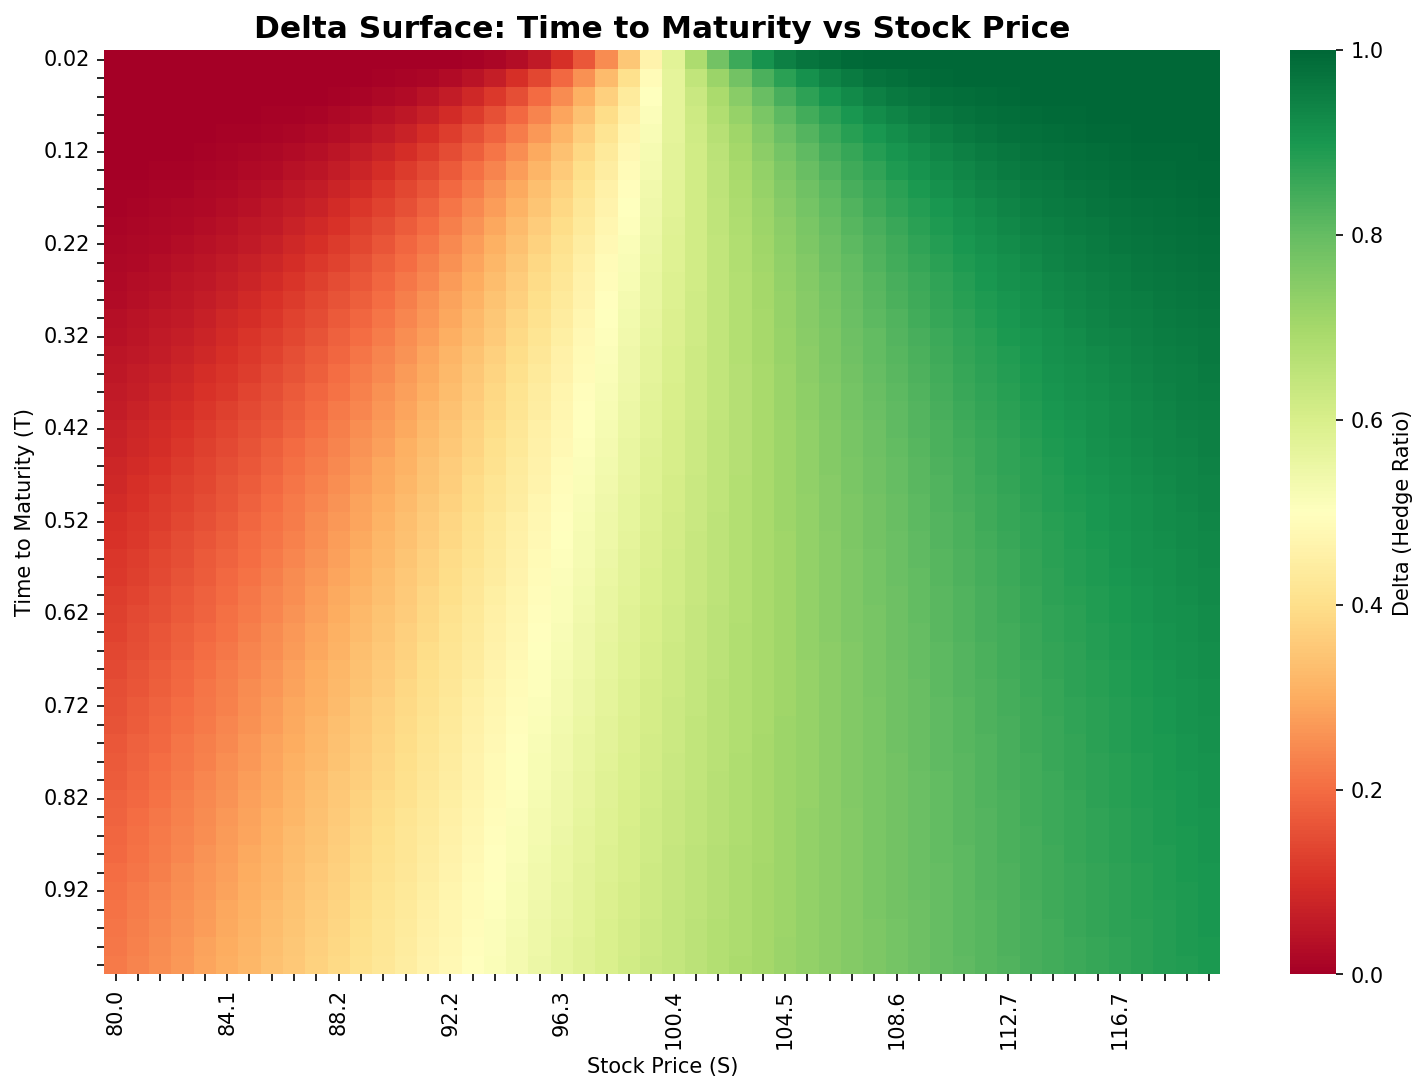

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Setup the Grid
# S from 80 to 120, T from 1 week (0.02) to 1 year (1.0)
S_vals = np.linspace(80, 120, 50)
T_vals = np.linspace(0.02, 1.0, 50)
S_grid, T_grid = np.meshgrid(S_vals, T_vals)

# 2. Calculate Delta for the entire grid
# Re-using your analytical calculator logic
K, r, sigma = 100, 0.05, 0.2
d1 = (np.log(S_grid / K) + (r + 0.5 * sigma**2) * T_grid) / (sigma * np.sqrt(T_grid))
delta_surface = norm.cdf(d1)

# 3. Professional Plotting
plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    delta_surface, 
    xticklabels=np.round(S_vals, 1), 
    yticklabels=np.round(T_vals, 2),
    cmap="RdYlGn",  # Red (OTM) to Green (ITM)
    cbar_kws={'label': 'Delta (Hedge Ratio)'}
)

# 4. Final Polish
plt.title("Delta Surface: Time to Maturity vs Stock Price", fontsize=15, fontweight='bold')
plt.xlabel("Stock Price (S)")
plt.ylabel("Time to Maturity (T)")

# Subsample ticks so the axes aren't crowded
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0: label.set_visible(False)
for i, label in enumerate(ax.get_yticklabels()):
    if i % 5 != 0: label.set_visible(False)

plt.show()


## Monte Carlo Visualization Functions

The following cell contains the production-quality visualization functions for Monte Carlo pricing analysis:

1. **Convergence plot** — MC price vs n_sims, with BS reference
2. **Payoff distribution** — histogram of terminal payoffs
3. **Confidence intervals** — CI width vs n_sims
4. **Variance reduction comparison** — bar chart

In [4]:
"""
Monte Carlo Visualization Module
=================================
Production-quality plots for Monte Carlo pricing analysis.

Plots:
    1. Convergence plot (MC price vs n_sims, with BS reference)
    2. Payoff distribution (histogram of terminal payoffs)
    3. Confidence intervals (CI width vs n_sims)
    4. Variance reduction comparison (bar chart)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from typing import Dict, Optional

# --- Consistent dark professional theme ---
STYLE_CONFIG = {
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
    "grid.alpha": 0.7,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.grid": True,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "legend.fontsize": 10,
}

# Color palette
COLORS = {
    "standard": "#58a6ff",
    "antithetic": "#f78166",
    "control": "#7ee787",
    "bs_ref": "#ffd700",
    "ci_fill": "#58a6ff",
    "hist_call": "#58a6ff",
    "hist_put": "#f78166",
}


def _apply_style():
    """Apply dark theme to current plot."""
    plt.rcParams.update(STYLE_CONFIG)


def plot_convergence(
    convergence_data: Dict,
    save_path: Optional[str] = None,
    show: bool = True,
) -> plt.Figure:
    """
    Plot Monte Carlo price convergence to Black-Scholes as N increases.

    Args:
        convergence_data: Output from convergence_analysis().
        save_path:        If provided, save figure to this path.
        show:             Whether to display the figure.

    Returns:
        matplotlib Figure object.
    """
    _apply_style()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    sim_sizes = convergence_data["sim_sizes"]
    bs_price = convergence_data["bs_price"]
    results = convergence_data["results"]

    # --- Left: Price vs N ---
    for method, color in [("standard", COLORS["standard"]),
                          ("antithetic", COLORS["antithetic"]),
                          ("control", COLORS["control"])]:
        if method not in results:
            continue
        prices = [r["price"] for r in results[method]]
        ci_lo = [r["ci_lower"] for r in results[method]]
        ci_hi = [r["ci_upper"] for r in results[method]]

        ax1.plot(sim_sizes, prices, 'o-', color=color, label=method.capitalize(),
                 linewidth=2, markersize=5, alpha=0.9)
        ax1.fill_between(sim_sizes, ci_lo, ci_hi, color=color, alpha=0.1)

    ax1.axhline(y=bs_price, color=COLORS["bs_ref"], linestyle="--",
                linewidth=2, label=f"Black-Scholes = {bs_price:.4f}", alpha=0.8)
    ax1.set_xscale("log")
    ax1.set_xlabel("Number of Simulations (N)", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Option Price ($)", fontsize=12, fontweight="bold")
    ax1.set_title("Monte Carlo Convergence", fontsize=14, fontweight="bold")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # --- Right: Absolute Error vs N ---
    for method, color in [("standard", COLORS["standard"]),
                          ("antithetic", COLORS["antithetic"]),
                          ("control", COLORS["control"])]:
        if method not in results:
            continue
        errors = [r["abs_error"] for r in results[method]]
        ax2.plot(sim_sizes, errors, 'o-', color=color, label=method.capitalize(),
                 linewidth=2, markersize=5, alpha=0.9)

    # Theoretical O(1/√N) line
    ref_err = results["standard"][0]["abs_error"] if "standard" in results else 1.0
    ref_n = sim_sizes[0]
    theoretical = [ref_err * np.sqrt(ref_n / n) for n in sim_sizes]
    ax2.plot(sim_sizes, theoretical, ':', color="#8b949e", linewidth=1.5,
             label=r"$O(1/\sqrt{N})$ reference", alpha=0.7)

    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel("Number of Simulations (N)", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Absolute Error ($)", fontsize=12, fontweight="bold")
    ax2.set_title("Error Convergence", fontsize=14, fontweight="bold")
    ax2.legend(loc="upper right")
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    fig.suptitle("Monte Carlo Pricing Engine — Convergence Analysis",
                 fontsize=16, fontweight="bold", color="#f0f6fc", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    if show:
        plt.show()

    return fig


def plot_payoff_distribution(
    S0: float,
    K: float,
    T: float,
    r: float,
    sigma: float,
    n_sims: int = 100_000,
    seed: int = 42,
    save_path: Optional[str] = None,
    show: bool = True,
) -> plt.Figure:
    """
    Plot histogram of simulated terminal prices and payoff distributions.
    """
    from monte_carlo import simulate_terminal_price, compute_payoff

    _apply_style()
    rng = np.random.default_rng(seed)
    ST = simulate_terminal_price(S0, r, sigma, T, n_sims, rng)

    call_payoff = compute_payoff(ST, K, "call")
    put_payoff = compute_payoff(ST, K, "put")
    discount = np.exp(-r * T)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    # 1. Terminal price distribution
    ax = axes[0]
    ax.hist(ST, bins=100, color=COLORS["standard"], alpha=0.7, edgecolor="none",
            density=True)
    ax.axvline(S0, color=COLORS["bs_ref"], linestyle="--", linewidth=2,
               label=f"S₀ = {S0:.0f}")
    ax.axvline(K, color=COLORS["antithetic"], linestyle="--", linewidth=2,
               label=f"K = {K:.0f}")
    ax.axvline(np.mean(ST), color="#7ee787", linestyle="-", linewidth=2,
               label=f"E[S_T] = {np.mean(ST):.2f}")
    ax.set_xlabel("Terminal Price (S_T)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Density", fontsize=11, fontweight="bold")
    ax.set_title("Terminal Price Distribution", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)

    # 2. Call payoff distribution
    ax = axes[1]
    nonzero_call = call_payoff[call_payoff > 0]
    ax.hist(nonzero_call, bins=80, color=COLORS["hist_call"], alpha=0.7,
            edgecolor="none", density=True)
    ax.axvline(np.mean(call_payoff), color=COLORS["bs_ref"], linestyle="--",
               linewidth=2, label=f"E[payoff] = {np.mean(call_payoff):.2f}")
    itm_pct = 100 * len(nonzero_call) / n_sims
    ax.set_xlabel("Call Payoff max(S_T − K, 0)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Density", fontsize=11, fontweight="bold")
    ax.set_title(f"Call Payoff | ITM = {itm_pct:.1f}%", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)

    # 3. Put payoff distribution
    ax = axes[2]
    nonzero_put = put_payoff[put_payoff > 0]
    ax.hist(nonzero_put, bins=80, color=COLORS["hist_put"], alpha=0.7,
            edgecolor="none", density=True)
    ax.axvline(np.mean(put_payoff), color=COLORS["bs_ref"], linestyle="--",
               linewidth=2, label=f"E[payoff] = {np.mean(put_payoff):.2f}")
    itm_pct_put = 100 * len(nonzero_put) / n_sims
    ax.set_xlabel("Put Payoff max(K − S_T, 0)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Density", fontsize=11, fontweight="bold")
    ax.set_title(f"Put Payoff | ITM = {itm_pct_put:.1f}%", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)

    fig.suptitle(f"Payoff Distributions | S₀={S0}, K={K}, T={T}, σ={sigma}, r={r} | N={n_sims:,}",
                 fontsize=14, fontweight="bold", color="#f0f6fc", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    if show:
        plt.show()
    return fig


def plot_confidence_intervals(
    convergence_data: Dict,
    method: str = "standard",
    save_path: Optional[str] = None,
    show: bool = True,
) -> plt.Figure:
    """
    Plot confidence interval width shrinking with increasing N.
    """
    _apply_style()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    sim_sizes = convergence_data["sim_sizes"]
    bs_price = convergence_data["bs_price"]
    data = convergence_data["results"][method]

    prices = [r["price"] for r in data]
    ci_lo = [r["ci_lower"] for r in data]
    ci_hi = [r["ci_upper"] for r in data]
    ci_widths = [r["ci_upper"] - r["ci_lower"] for r in data]
    std_errors = [r["std_error"] for r in data]

    color = COLORS.get(method, COLORS["standard"])

    # Left: Price with CI bars
    ax1.errorbar(sim_sizes, prices,
                 yerr=[(p - lo) for p, lo in zip(prices, ci_lo)],
                 fmt='o-', color=color, ecolor=color, elinewidth=1.5,
                 capsize=4, linewidth=2, markersize=6, alpha=0.9,
                 label=f"{method.capitalize()} MC")
    ax1.axhline(y=bs_price, color=COLORS["bs_ref"], linestyle="--",
                linewidth=2, label=f"BS = {bs_price:.4f}", alpha=0.8)
    ax1.set_xscale("log")
    ax1.set_xlabel("Number of Simulations", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Option Price ($)", fontsize=12, fontweight="bold")
    ax1.set_title(f"95% Confidence Intervals ({method.capitalize()})",
                  fontsize=13, fontweight="bold")
    ax1.legend()
    ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    # Right: CI width and SE
    ax2.plot(sim_sizes, ci_widths, 'o-', color=color, linewidth=2,
             markersize=6, label="CI Width (95%)")
    ax2.plot(sim_sizes, std_errors, 's--', color=COLORS["antithetic"],
             linewidth=2, markersize=5, label="Standard Error", alpha=0.8)

    # Theoretical 1/√N scaling
    ref_w = ci_widths[0]
    ref_n = sim_sizes[0]
    theoretical_w = [ref_w * np.sqrt(ref_n / n) for n in sim_sizes]
    ax2.plot(sim_sizes, theoretical_w, ':', color="#8b949e", linewidth=1.5,
             label=r"$O(1/\sqrt{N})$", alpha=0.7)

    ax2.set_xscale("log")
    ax2.set_yscale("log")
    ax2.set_xlabel("Number of Simulations", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Width / Error ($)", fontsize=12, fontweight="bold")
    ax2.set_title("CI Width & Standard Error", fontsize=13, fontweight="bold")
    ax2.legend()
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    fig.suptitle("Confidence Interval Analysis",
                 fontsize=15, fontweight="bold", color="#f0f6fc", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    if show:
        plt.show()
    return fig


def plot_variance_reduction(
    comparison_data: Dict,
    save_path: Optional[str] = None,
    show: bool = True,
) -> plt.Figure:
    """
    Bar chart comparing Standard MC, Antithetic, and Control Variate methods.
    Shows price accuracy, variance, standard error, and variance reduction ratio.
    """
    _apply_style()
    fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))

    methods = ["standard", "antithetic", "control"]
    labels = ["Standard MC", "Antithetic", "Control Variate"]
    colors = [COLORS["standard"], COLORS["antithetic"], COLORS["control"]]
    bs_price = comparison_data["bs_price"]

    # 1. Price comparison
    ax = axes[0]
    prices = [comparison_data[m]["price"] for m in methods]
    bars = ax.bar(labels, prices, color=colors, alpha=0.85, edgecolor="none",
                  width=0.6)
    ax.axhline(y=bs_price, color=COLORS["bs_ref"], linestyle="--", linewidth=2,
               label=f"BS = {bs_price:.4f}")
    ax.set_ylabel("Price ($)", fontsize=11, fontweight="bold")
    ax.set_title("MC Price", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    # Add value labels
    for bar, p in zip(bars, prices):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{p:.4f}", ha="center", va="bottom", fontsize=9, color="#c9d1d9")

    # 2. Variance
    ax = axes[1]
    variances = [comparison_data[m]["variance"] for m in methods]
    bars = ax.bar(labels, variances, color=colors, alpha=0.85, edgecolor="none",
                  width=0.6)
    ax.set_ylabel("Variance", fontsize=11, fontweight="bold")
    ax.set_title("Sample Variance", fontsize=13, fontweight="bold")
    for bar, v in zip(bars, variances):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9, color="#c9d1d9")

    # 3. Standard Error
    ax = axes[2]
    se = [comparison_data[m]["std_error"] for m in methods]
    bars = ax.bar(labels, se, color=colors, alpha=0.85, edgecolor="none",
                  width=0.6)
    ax.set_ylabel("Std Error ($)", fontsize=11, fontweight="bold")
    ax.set_title("Standard Error", fontsize=13, fontweight="bold")
    for bar, s in zip(bars, se):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0001,
                f"{s:.6f}", ha="center", va="bottom", fontsize=9, color="#c9d1d9")

    # 4. Variance Reduction Ratio
    ax = axes[3]
    ratios = [1.0]  # Standard baseline
    for m in ["antithetic", "control"]:
        vr = comparison_data[m].get("variance_reduction_ratio")
        ratios.append(vr if vr is not None else 0)
    bars = ax.bar(labels, ratios, color=colors, alpha=0.85, edgecolor="none",
                  width=0.6)
    ax.axhline(y=1.0, color="#8b949e", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_ylabel("Ratio (× improvement)", fontsize=11, fontweight="bold")
    ax.set_title("Variance Reduction Ratio", fontsize=13, fontweight="bold")
    for bar, ratio in zip(bars, ratios):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{ratio:.2f}×", ha="center", va="bottom", fontsize=10,
                color="#c9d1d9", fontweight="bold")

    fig.suptitle("Variance Reduction Comparison",
                 fontsize=15, fontweight="bold", color="#f0f6fc", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
    if show:
        plt.show()
    return fig
